# 18 — Aspect visuals (coast bands)

Charts over the Claude silver labels (`TOPIC_ASPECTS` + `REVIEW_TOPICS`) for the 3 coastal distance bands:

| # | Chart | Style |
|---|-------|-------|
| 1 | `key_aspect` bars stacked by distance band | horizontal stacked bar |
| 1b | aspect share within each band (slope chart) | unequal-width slope |
| 1c | aspect share vs continuous distance to coastline | kernel-smoothed line |
| 2 | top-5 `sub_aspect` per `key_aspect`, stacked by band | horizontal stacked bar × 5 panels |
| 2b | sub_aspect composition per band (100% stacked) | 100% stacked × 5 panels |
| 2c | sub_aspects by number of supporting topics | single horizontal bar |
| R | ridgeline: where each aspect concentrates on the distance axis | KDE ridgeline |
| B | bubble strip: topic × distance × sentiment | scatter |

**Two metrics:**
- **Volume** (`weight × n_reviews`): aspect-level shares.
- **Sub_aspect support** (`Σ weight × log(1 + n_reviews)`): dampened; requires ≥ 2 topics.

**Prerequisite:** run `llm_label_submit.py` + `llm_label_retrieve.py` for coast band runs first.  
**Year slice visuals → see `22_aspect_visuals_year.ipynb`.**

In [ ]:
import sys, json
from pathlib import Path
sys.path.append("../src")

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import llm_label as ll

IMG_DIR = Path("../img")
IMG_DIR.mkdir(exist_ok=True)

ASPECT_ORDER = ["facility", "amenity", "service", "experience", "loyalty"]
ASPECT_COLORS = {
    "facility":   "#4878a8",
    "amenity":    "#6a9f58",
    "service":    "#e49444",
    "experience": "#d1605e",
    "loyalty":    "#a87ca8",
}

# Coast bands: A = beachfront, B = near-coast, C = inland.
# Updated 2026-06: B = 0.1–1.0 km, C = ≥ 1.0 km (was 0.1–0.5 / ≥0.5).
BAND_ORDER = ["Beachfront (<0.1 km)", "Near-coast (0.1–1.0 km)", "Inland (≥1.0 km)"]
BAND_COLORS = {
    BAND_ORDER[0]: "#0277bd",
    BAND_ORDER[1]: "#26a69a",
    BAND_ORDER[2]: "#b8860b",
}
TITLE_KW = dict(fontsize=16, fontweight="bold", color="#36648B", loc="left")

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.titlesize": 14, "axes.labelsize": 12,
                     "xtick.labelsize": 11, "ytick.labelsize": 11})

## Load labeled data
One row per (run, topic, aspect) with its weighted review count.

In [ ]:
con = duckdb.connect(str(ll.DB_PATH), read_only=True)

df = con.execute("""
    SELECT rt.run_id, rt.topic_id, ta.key_aspect, ta.weight, ta.sentiment,
           ta.sub_aspects, COUNT(*) AS n_reviews
    FROM REVIEW_TOPICS rt
    JOIN TOPIC_ASPECTS ta
      ON rt.run_id = ta.run_id AND rt.topic_id = ta.topic_id
    WHERE rt.topic_id != -1 AND ta.key_aspect != 'other'
    GROUP BY ALL
""").df()
con.close()

if df.empty:
    raise RuntimeError("TOPIC_ASPECTS is empty - run the labeling batch first "
                       "(notebook 17, then llm_label_submit.py / llm_label_retrieve.py).")

df["weighted"] = df["weight"] * df["n_reviews"]
df["language"] = df["run_id"].str[-2:]

coast = df[df["run_id"].str.startswith("coast_band_")].copy()
# A=Beachfront, B=Near-coast, C=Inland — matches BAND_ORDER[0..2]
coast["band"] = (coast["run_id"].str.extract(r"coast_band_([ABC])")[0]
                 .map(dict(zip(["A", "B", "C"], BAND_ORDER))))

year = df[df["run_id"].str.startswith("year_")].copy()
year["year"] = year["run_id"].str.extract(r"year_(\d{4})")[0].astype(int)

print(f"labeled aspect rows: coast={len(coast)}, year={len(year)}")
print("labeled runs:", sorted(df.run_id.unique()))

In [15]:
df.head()

,run_id,topic_id,key_aspect,weight,sentiment,sub_aspects,n_reviews,weighted,language
0,coast_band_C_vi,69,service,1.00,negative,"[""service_quality"", ""overall_rating""]",111,111.000000,vi
1,coast_band_C_vi,57,experience,0.25,negative,"[""overall_satisfaction"", ""value_for_money""]",143,35.750000,vi
2,coast_band_C_vi,78,facility,1.00,negative,"[""room_lighting"", ""room_size"", ""ventilation""]",95,95.000000,vi
3,coast_band_C_vi,94,experience,0.30,negative,"[""value_for_money""]",75,22.500001,vi
4,coast_band_C_vi,17,service,0.25,positive,"[""staff_friendliness"", ""staff_attentiveness""]",608,152.000000,vi


In [20]:
df.groupby('run_id')['n_reviews'].sum()

run_id
coast_band_A_en     29165
coast_band_A_vi     39983
coast_band_B_en     27326
coast_band_B_vi     30518
coast_band_C_en    147983
coast_band_C_vi     81179
Name: n_reviews, dtype: int64

## Chart 1 — Reviews per key_aspect, stacked by distance band
5 horizontal bars (one per aspect), 3 colors (one per band), value labels per segment —
same layout as the ggplot stacked-`geom_col` + `coord_flip` reference.

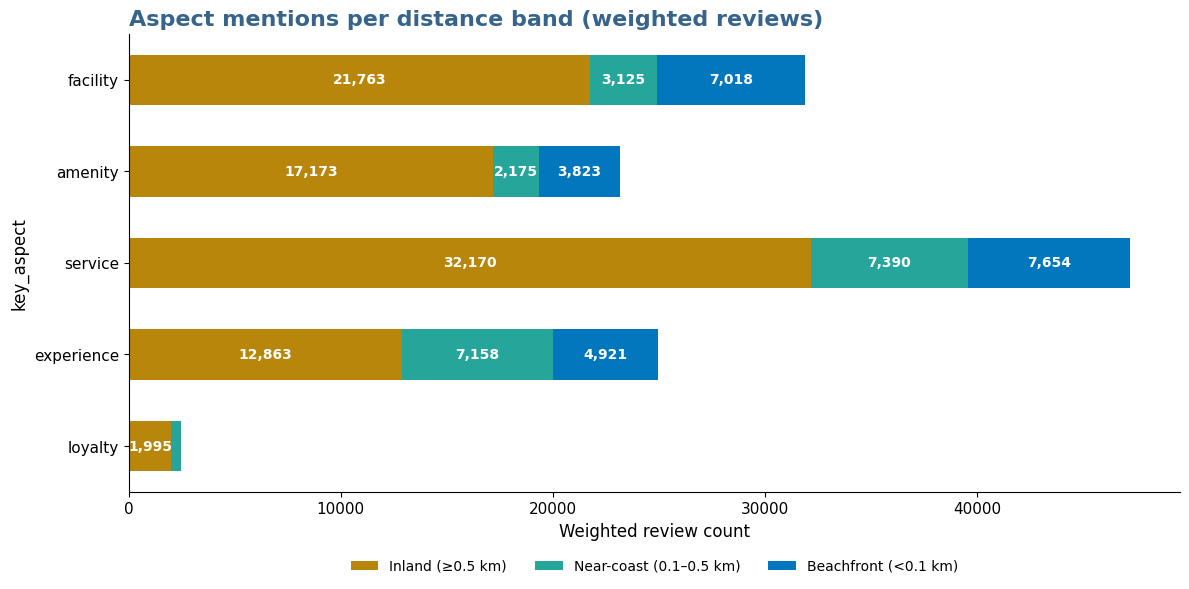

In [33]:
pivot = (coast.groupby(["key_aspect", "band"])["weighted"].sum()
         .unstack("band")
         .reindex(index=ASPECT_ORDER, columns=BAND_ORDER)
         .fillna(0))

fig, ax = plt.subplots(figsize=(12, 6))
left = pd.Series(0.0, index=pivot.index)
for band in BAND_ORDER:
    vals = pivot[band]
    ax.barh(pivot.index, vals, left=left, height=0.55,
            color=BAND_COLORS[band], label=band)
    for aspect, v, l in zip(pivot.index, vals, left):
        if v > pivot.to_numpy().sum() * 0.01:  # skip labels on tiny slivers
            ax.text(l + v / 2, aspect, f"{v:,.0f}",
                    ha="center", va="center", color="white",
                    fontsize=10, fontweight="bold")
    left += vals

ax.invert_yaxis()
ax.set_title("Aspect mentions per distance band (weighted reviews)", **TITLE_KW)
ax.set_xlabel("Weighted review count")
ax.set_ylabel("key_aspect")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
fig.tight_layout()
fig.savefig(IMG_DIR / "18_coast_aspect_stacked.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use globals defined in cell-1 (ASPECT_ORDER, ASPECT_COLORS, BAND_ORDER, BAND_COLORS)

# -----------------------------
# Unequal x spacing — fixed visual layout (proportions kept), not literal km.
# 10% beachfront | 40% near-coast | 50% inland
# -----------------------------
segment_widths = [0.10, 0.40, 0.50]
segment_edges = np.r_[0, np.cumsum(segment_widths)]   # [0.0, 0.1, 0.5, 1.0]
x_pos = (segment_edges[:-1] + segment_edges[1:]) / 2  # [0.05, 0.30, 0.75]

tick_labels = [
    "Beachfront\n(<0.1 km)",
    "Near-coast\n(0.1–1.0 km)",
    "Inland\n(≥1.0 km)"
]

pivot = (
    coast.groupby(["key_aspect", "band"])["weighted"]
    .sum()
    .unstack("band")
    .reindex(index=ASPECT_ORDER, columns=BAND_ORDER)
    .fillna(0)
)

pivot_pct = pivot.div(pivot.sum(axis=0), axis=1).mul(100).fillna(0)

fig, ax = plt.subplots(figsize=(11.5, 6.5))

for i in range(len(segment_widths)):
    ax.axvspan(segment_edges[i], segment_edges[i+1], alpha=0.06, color="gray", zorder=0)

for edge in segment_edges:
    ax.axvline(edge, color="lightgray", linewidth=1, linestyle="--", zorder=1)

for aspect in ASPECT_ORDER:
    y = pivot_pct.loc[aspect, BAND_ORDER].values
    ax.plot(x_pos, y, marker="o", markersize=8, linewidth=2.8,
            color=ASPECT_COLORS[aspect], label=aspect)
    ax.text(x_pos[-1] + 0.03, y[-1], aspect,
            color=ASPECT_COLORS[aspect], fontsize=10, fontweight="bold", va="center")

ax.set_xlim(0, 1.10)
ax.set_xticks(x_pos)
ax.set_xticklabels(tick_labels)
ax.set_ylabel("Share within distance band (%)")
ax.set_xlabel("Distance band (segment width is a fixed visual layout, not literal km)")
ax.set_title("How aspect emphasis changes from coastline to inland", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, title="Aspect")

fig.tight_layout()
fig.savefig(IMG_DIR / "aspect_slope_unequal_distance.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 1c — Aspect share vs **continuous** distance to coastline (smooth)

Instead of 3 coarse band points, every review keeps its own `distance2coastline` and the
5 aspect shares are computed with a **Gaussian kernel over log-distance** (a moving
weighted window), so the lines are genuinely smooth. Dashed verticals mark the original
band boundaries (0.1 / 1.0 km). Tune `BANDWIDTH` (bigger = smoother).

> Caveat: aspect labels live at *topic* level — all reviews of a topic share its aspect
> mix. The curve's shape comes from how differently-labeled topics distribute over
> distance, which is exactly what we want to see.

In [ ]:
import numpy as np

# --- per-review distances: each review keeps its own distance2coastline ---
con = duckdb.connect(str(ll.DB_PATH), read_only=True)
rv = con.execute("""
    SELECT r.distance2coastline AS dist, ta.key_aspect, ta.weight
    FROM REVIEW_TOPICS rt
    JOIN TOPIC_ASPECTS ta ON rt.run_id = ta.run_id AND rt.topic_id = ta.topic_id
    JOIN REVIEW_DATA r    ON rt.review_id = r.review_id
    WHERE rt.run_id LIKE 'coast_band_%' AND rt.topic_id != -1
      AND ta.key_aspect != 'other' AND r.distance2coastline IS NOT NULL
""").df()
con.close()
print(f"{len(rv):,} review-aspect rows, distance {rv.dist.min():.3f}-{rv.dist.max():.2f} km")

# --- Gaussian kernel smoothing over log10(distance) ---
BANDWIDTH = 0.18   # in log10-km; bigger = smoother
GRID_N = 80

logd = np.log10(rv["dist"].clip(lower=0.01).to_numpy())
w = rv["weight"].to_numpy()
codes = pd.Categorical(rv["key_aspect"], categories=ASPECT_ORDER).codes

grid = np.linspace(np.quantile(logd, 0.01), np.quantile(logd, 0.99), GRID_N)
mass = np.zeros((GRID_N, len(ASPECT_ORDER)))
for i, x in enumerate(grid):
    kw = np.exp(-0.5 * ((logd - x) / BANDWIDTH) ** 2) * w
    mass[i] = np.bincount(codes, weights=kw, minlength=len(ASPECT_ORDER))
share = 100 * mass / mass.sum(axis=1, keepdims=True)
dist_km = 10 ** grid

# --- plot ---
fig, ax = plt.subplots(figsize=(12, 6.5))
for j, aspect in enumerate(ASPECT_ORDER):
    ax.plot(dist_km, share[:, j], linewidth=2.8,
            color=ASPECT_COLORS[aspect], label=aspect)
    ax.text(dist_km[-1] * 1.05, share[-1, j], aspect,
            color=ASPECT_COLORS[aspect], fontsize=10,
            fontweight="bold", va="center")

for edge, name in [(0.1, "0.1 km"), (1.0, "1.0 km")]:
    ax.axvline(edge, color="gray", linestyle="--", linewidth=1, alpha=0.6)
    ax.text(edge, ax.get_ylim()[1], f" {name}", color="gray",
            fontsize=9, va="top")

ax.set_xscale("log")
ax.set_xlabel("Distance to coastline (km, log scale)")
ax.set_ylabel("Aspect share (%)")
ax.set_title("Aspect share vs distance to coastline (kernel-smoothed)", **TITLE_KW)
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=5, frameon=False)
fig.tight_layout()
fig.savefig(IMG_DIR / "18_coast_aspect_smooth.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 2 — Top-5 sub_aspects underneath each key_aspect (coast)

One panel per aspect; within it, that aspect's top-5 `sub_aspect` bars, stacked by the 3 bands.

**Ranking metric (fixed):** `weight × n_reviews` was misleading — a *single* topic with
weight 0.25 but tens of thousands of reviews pushed its sub_aspect (e.g. `amenities`)
into the top-5. Now:

- **support score = Σ over topics of `weight × log(1 + n_reviews)`** — log damping means
  a topic 10× bigger only counts ~1.3× more, so rankings reflect *how many topics*
  mention a sub_aspect, not one giant cluster;
- a sub_aspect needs **≥ 2 supporting topics** to be ranked (falls back to 1 if an
  aspect's vocabulary is too sparse);
- generic labels that just repeat the aspect name (`amenities` under amenity,
  `service_quality`→ kept, but bare `service`/`facilities`/… dropped) are excluded.

Bars are annotated with the number of supporting topics.

In [ ]:
import numpy as np

GENERIC_SUBS = {
    "facility":   {"facility", "facilities", "room", "cleanliness", "hygiene"},
    "amenity":    {"amenity", "amenities", "location", "place", "area"},
    "service":    {"service", "staff"},
    "experience": {"experience"},
    "loyalty":    {"loyalty"},
}


def explode_subs(d: pd.DataFrame) -> pd.DataFrame:
    """One row per (topic, aspect, sub_aspect) with a damped support score."""
    s = d.copy()
    s["sub_aspect"] = s["sub_aspects"].apply(json.loads)
    s = s.explode("sub_aspect").dropna(subset=["sub_aspect"])
    s["topic_key"] = s["run_id"] + "/" + s["topic_id"].astype(str)
    s["support"] = s["weight"] * np.log1p(s["n_reviews"])
    return s


def top_subaspects(s: pd.DataFrame, aspect: str, k: int = 5,
                   min_topics: int = 2) -> pd.Index:
    """Top-k sub_aspects of one aspect by damped support, requiring multi-topic support."""
    d = s[(s["key_aspect"] == aspect)
          & ~s["sub_aspect"].isin(GENERIC_SUBS.get(aspect, set()))]
    g = d.groupby("sub_aspect").agg(n_topics=("topic_key", "nunique"),
                                    score=("support", "sum"))
    eligible = g[g["n_topics"] >= min_topics]
    if len(eligible) < k:
        eligible = g
    return eligible.sort_values("score", ascending=False).head(k)


subs = explode_subs(coast)

fig, axes = plt.subplots(len(ASPECT_ORDER), 1,
                         figsize=(12, 3.2 * len(ASPECT_ORDER)), sharex=False)

for ax, aspect in zip(axes, ASPECT_ORDER):
    top = top_subaspects(subs, aspect)
    if top.empty:
        ax.set_visible(False)
        continue
    d = subs[(subs["key_aspect"] == aspect) & subs["sub_aspect"].isin(top.index)]
    p = (d.groupby(["sub_aspect", "band"])["support"].sum()
         .unstack("band").reindex(index=top.index, columns=BAND_ORDER).fillna(0))

    left = pd.Series(0.0, index=p.index)
    for band in BAND_ORDER:
        ax.barh(p.index, p[band], left=left, height=0.6,
                color=BAND_COLORS[band], label=band)
        left += p[band]
    for sub_name, total in left.items():
        ax.text(total, sub_name, f"  {top.loc[sub_name, 'n_topics']} topics",
                va="center", fontsize=9, color="dimgray")

    ax.invert_yaxis()
    ax.set_title(aspect.upper(), fontsize=13, fontweight="bold",
                 color=ASPECT_COLORS[aspect], loc="left")
    ax.set_xlabel("")

axes[-1].set_xlabel("support score  ( Σ weight × log(1 + reviews) )")
axes[0].legend(loc="lower right", fontsize=9, frameon=False)
fig.suptitle("Top-5 sub_aspects per key_aspect — coast bands",
             fontsize=16, fontweight="bold", color="#36648B", x=0.01, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(IMG_DIR / "18_coast_subaspects.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 2b — Sub_aspect composition per band (100% stacked, top-10 + others)

For each `key_aspect`: three 100%-stacked bars — **Beachfront / Near-coast / Inland** —
showing what that aspect is *made of* in each band. Segments are the aspect's **top-10
sub_aspects** (support-ranked, ordered large → small) and everything ranked 11+ is
collapsed into a gray **others** bucket.

- Percentages = share of sub_aspect *support* within (band, aspect) — same damped metric
  as chart 2, so one giant topic can't dominate a band's composition.
- `n ≈` at the end of each bar is the **weighted review count** of that aspect in that
  band (the volume behind the percentages).

Requires chart 2's cell to have run first (`subs`, `top_subaspects`, `GENERIC_SUBS`).

In [ ]:
TOP_K = 10
OTHER_COLOR = "#b0b0b0"
SEG_COLORS = list(plt.cm.tab20.colors)

fig, axes = plt.subplots(len(ASPECT_ORDER), 1,
                         figsize=(13, 4.0 * len(ASPECT_ORDER)))

for ax, aspect in zip(axes, ASPECT_ORDER):
    d = subs[(subs["key_aspect"] == aspect)
             & ~subs["sub_aspect"].isin(GENERIC_SUBS.get(aspect, set()))].copy()
    if d.empty:
        ax.set_visible(False)
        continue

    top = top_subaspects(subs, aspect, k=TOP_K)              # top-10, support-ranked
    d["sub_grp"] = np.where(d["sub_aspect"].isin(top.index), d["sub_aspect"], "others")
    seg_order = list(top.index) + ["others"]                  # large -> small, others last

    p = (d.groupby(["band", "sub_grp"])["support"].sum()
         .unstack("sub_grp").reindex(index=BAND_ORDER, columns=seg_order).fillna(0))
    pct = p.div(p.sum(axis=1), axis=0).mul(100).fillna(0)

    # review volume per band for this aspect (the "count value" annotation)
    nrev = (coast[coast["key_aspect"] == aspect]
            .groupby("band")["weighted"].sum().reindex(BAND_ORDER).fillna(0))

    left = pd.Series(0.0, index=pct.index)
    for i, seg in enumerate(seg_order):
        color = OTHER_COLOR if seg == "others" else SEG_COLORS[i % len(SEG_COLORS)]
        ax.barh(pct.index, pct[seg], left=left, height=0.62, color=color, label=seg)
        for band, v, l in zip(pct.index, pct[seg], left):
            if v > 4:
                ax.text(l + v / 2, band, f"{v:.0f}%", ha="center", va="center",
                        fontsize=8.5, color="white", fontweight="bold")
        left += pct[seg]

    for band in BAND_ORDER:
        ax.text(101.5, band, f"n ≈ {nrev[band]:,.0f}", va="center",
                fontsize=9, color="dimgray")

    ax.set_xlim(0, 116)
    ax.invert_yaxis()
    ax.set_title(aspect.upper(), fontsize=13, fontweight="bold",
                 color=ASPECT_COLORS[aspect], loc="left")
    ax.set_xlabel("")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=4,
              fontsize=8.5, frameon=False)

axes[-1].set_xlabel("% of sub_aspect support within the band")
fig.suptitle("Sub_aspect composition per band, within each key_aspect "
             f"(top {TOP_K} + others)",
             fontsize=16, fontweight="bold", color="#36648B", x=0.01, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.99], h_pad=3.0)
fig.savefig(IMG_DIR / "18_coast_subaspect_composition.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 2c — Sub_aspects by number of supporting topics (top-20 + others)

One horizontal bar per sub_aspect name, value = **how many distinct topics mention it**
(across all 6 coast runs). The 20 most-supported sub_aspects are shown individually,
colored by their dominant `key_aspect`; everything ranked 21+ is collapsed into one gray
**others** bar whose value is the *total* mention count of the remainder.

This is the purest robustness view — no review counts at all, just topic support — so a
sub_aspect that one giant topic mentions once sits at the very bottom, no matter how many
reviews that topic has. Requires chart 2's cell (`subs`, `GENERIC_SUBS`).

In [ ]:
TOP_N = 20

# drop generic labels (sub_aspect that just repeats its own key_aspect)
mask = ~subs.apply(lambda r: r["sub_aspect"] in GENERIC_SUBS.get(r["key_aspect"], set()),
                   axis=1)
d = subs[mask]

# how many distinct topics mention each sub_aspect
g = d.groupby("sub_aspect")["topic_key"].nunique().rename("n_topics")

# dominant key_aspect per sub_aspect (for bar color)
dom = (d.groupby(["sub_aspect", "key_aspect"])["topic_key"].nunique()
       .reset_index()
       .sort_values("topic_key", ascending=False)
       .drop_duplicates("sub_aspect")
       .set_index("sub_aspect")["key_aspect"])

top = g.nlargest(TOP_N)
rest = g.drop(top.index)
others_total = int(rest.sum())          # total topic-mentions of everything ranked 21+

labels = list(top.index) + [f"others ({len(rest)} sub_aspects)"]
values = list(top.values) + [others_total]
colors = [ASPECT_COLORS[dom[s]] for s in top.index] + ["#b0b0b0"]

fig, ax = plt.subplots(figsize=(11, 0.42 * len(labels) + 2))
bars = ax.barh(labels, values, height=0.65, color=colors)
for label, v in zip(labels, values):
    ax.text(v, label, f" {v}", va="center", fontsize=9.5, color="dimgray")

ax.invert_yaxis()
n_total_topics = d["topic_key"].nunique()
ax.set_title(f"Sub_aspects by number of supporting topics — coast runs "
             f"(top {TOP_N} of {len(g)}, {n_total_topics} topics total)", **TITLE_KW)
ax.set_xlabel("Number of topics mentioning the sub_aspect "
              "(others = total mentions of rank 21+)")

handles = [plt.Rectangle((0, 0), 1, 1, color=ASPECT_COLORS[a]) for a in ASPECT_ORDER]
handles.append(plt.Rectangle((0, 0), 1, 1, color="#b0b0b0"))
ax.legend(handles, ASPECT_ORDER + ["others"], loc="lower right",
          fontsize=9, frameon=False, title="colored by dominant key_aspect")

fig.tight_layout()
fig.savefig(IMG_DIR / "18_coast_subaspect_topic_counts.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 2 — Top-5 sub_aspects underneath each key_aspect (coast)
One panel per aspect; within it, that aspect's top-5 `sub_aspect` bars, stacked by the 3 bands.

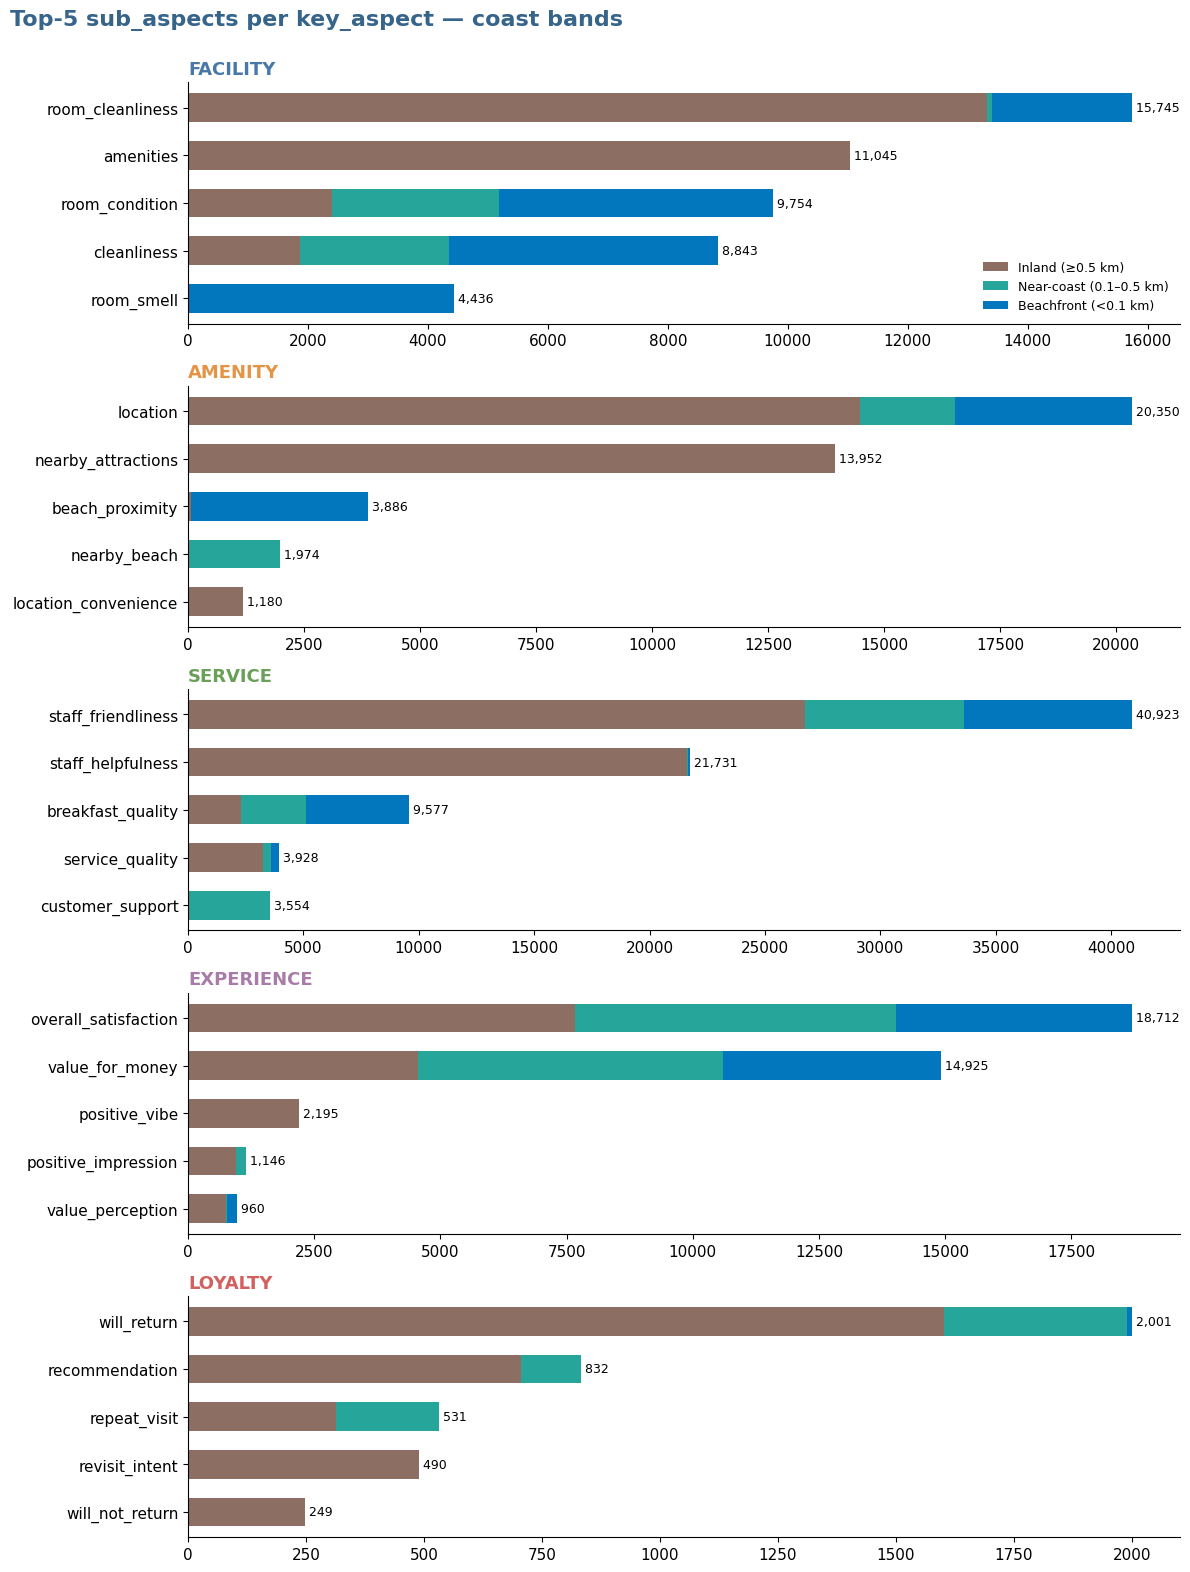

In [28]:
subs = coast.copy()
subs["sub_aspect"] = subs["sub_aspects"].apply(json.loads)
subs = subs.explode("sub_aspect").dropna(subset=["sub_aspect"])

fig, axes = plt.subplots(len(ASPECT_ORDER), 1, figsize=(12, 3.2 * len(ASPECT_ORDER)),
                         sharex=False)

for ax, aspect in zip(axes, ASPECT_ORDER):
    d = subs[subs["key_aspect"] == aspect]
    if d.empty:
        ax.set_visible(False)
        continue
    top5 = d.groupby("sub_aspect")["weighted"].sum().nlargest(5).index
    p = (d[d["sub_aspect"].isin(top5)]
         .groupby(["sub_aspect", "band"])["weighted"].sum()
         .unstack("band").reindex(index=top5, columns=BAND_ORDER).fillna(0))

    left = pd.Series(0.0, index=p.index)
    for band in BAND_ORDER:
        ax.barh(p.index, p[band], left=left, height=0.6,
                color=BAND_COLORS[band], label=band)
        left += p[band]
    for sub_name, total in left.items():
        ax.text(total, sub_name, f" {total:,.0f}", va="center", fontsize=9)

    ax.invert_yaxis()
    ax.set_title(aspect.upper(), fontsize=13, fontweight="bold",
                 color=ASPECT_COLORS[aspect], loc="left")
    ax.set_xlabel("")

axes[0].legend(loc="lower right", fontsize=9, frameon=False)
fig.suptitle("Top-5 sub_aspects per key_aspect — coast bands",
             fontsize=16, fontweight="bold", color="#36648B", x=0.01, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(IMG_DIR / "18_coast_subaspects.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
if year.empty:
    print("No year runs labeled yet - run llm_label_submit.py --all first.")
else:
    ysubs = explode_subs(year)  # same damped support score as chart 2

    fig, axes = plt.subplots(len(ASPECT_ORDER), 1,
                             figsize=(12, 3.4 * len(ASPECT_ORDER)), sharex=True)
    xticks = sorted(year["year"].unique())

    for ax, aspect in zip(axes, ASPECT_ORDER):
        top = top_subaspects(ysubs, aspect)
        if top.empty:
            ax.set_visible(False)
            continue
        d = ysubs[(ysubs["key_aspect"] == aspect) & ysubs["sub_aspect"].isin(top.index)]
        p = (d.groupby(["year", "sub_aspect"])["support"].sum()
             .unstack("sub_aspect").reindex(columns=top.index).fillna(0))
        for i, sub_name in enumerate(top.index):
            ax.plot(p.index, p[sub_name], marker="o", linewidth=2,
                    alpha=1 - 0.15 * i, color=ASPECT_COLORS[aspect], label=sub_name)
        ax.set_title(aspect.upper(), fontsize=13, fontweight="bold",
                     color=ASPECT_COLORS[aspect], loc="left")
        ax.grid(axis="y", alpha=0.3)
        ax.set_ylabel("support score")
        ax.legend(fontsize=9, ncol=2, frameon=False)

    axes[-1].set_xticks(xticks)
    axes[-1].set_xlabel("Year")
    fig.suptitle("Top-5 sub_aspects per key_aspect over years",
                 fontsize=16, fontweight="bold", color="#36648B", x=0.01, ha="left")
    fig.tight_layout(rect=[0, 0, 1, 0.99])
    fig.savefig(IMG_DIR / "18_year_subaspect_lines.png", dpi=150, bbox_inches="tight")
    plt.show()

In [7]:
if year.empty:
    print("No year runs labeled yet - run llm_label_submit.py --all first.")
else:
    ysubs = year.copy()
    ysubs["sub_aspect"] = ysubs["sub_aspects"].apply(json.loads)
    ysubs = ysubs.explode("sub_aspect").dropna(subset=["sub_aspect"])

    fig, axes = plt.subplots(len(ASPECT_ORDER), 1,
                             figsize=(12, 3.4 * len(ASPECT_ORDER)), sharex=True)
    xticks = sorted(year["year"].unique())

    for ax, aspect in zip(axes, ASPECT_ORDER):
        d = ysubs[ysubs["key_aspect"] == aspect]
        if d.empty:
            ax.set_visible(False)
            continue
        top5 = d.groupby("sub_aspect")["weighted"].sum().nlargest(5).index
        p = (d[d["sub_aspect"].isin(top5)]
             .groupby(["year", "sub_aspect"])["weighted"].sum()
             .unstack("sub_aspect").reindex(columns=top5).fillna(0))
        for i, sub_name in enumerate(top5):
            ax.plot(p.index, p[sub_name], marker="o", linewidth=2,
                    alpha=1 - 0.15 * i, color=ASPECT_COLORS[aspect], label=sub_name)
        ax.set_title(aspect.upper(), fontsize=13, fontweight="bold",
                     color=ASPECT_COLORS[aspect], loc="left")
        ax.grid(axis="y", alpha=0.3)
        ax.legend(fontsize=9, ncol=2, frameon=False)

    axes[-1].set_xticks(xticks)
    axes[-1].set_xlabel("Year")
    fig.suptitle("Top-5 sub_aspects per key_aspect over years",
                 fontsize=16, fontweight="bold", color="#36648B", x=0.01, ha="left")
    fig.tight_layout(rect=[0, 0, 1, 0.99])
    fig.savefig(IMG_DIR / "18_year_subaspect_lines.png", dpi=150, bbox_inches="tight")
    plt.show()

No year runs labeled yet - run llm_label_submit.py --all first.


## Chart R — Ridgeline: where each aspect concentrates on the distance axis

One `scipy` Gaussian KDE ridge per `key_aspect` over `log10(distance2coastline)`. Each
review is hard-assigned to its topic's **highest-weight aspect**. Every ridge is
normalised to the same peak height, so the curve shows each aspect's *distribution shape*
(not its absolute volume). The fill under each ridge is colored by **distance band**
(blue beachfront `<0.1` · teal near-coast `0.1–1.0` · gold inland `≥1.0`), the outline is
the aspect color, and the numbers are the **review count per band section**. Dashed
verticals mark the 0.1 / 1.0 km boundaries.

> Complements chart 1c (aspect *share* %) and the per-band counts above (absolute volume).

In [ ]:
from scipy.stats import gaussian_kde

con = duckdb.connect(str(ll.DB_PATH), read_only=True)
rv = con.execute("""
    WITH top_aspect AS (
        SELECT run_id, topic_id, key_aspect
        FROM (
            SELECT run_id, topic_id, key_aspect,
                   ROW_NUMBER() OVER (PARTITION BY run_id, topic_id
                                      ORDER BY weight DESC) AS rn
            FROM TOPIC_ASPECTS
            WHERE key_aspect != 'other'
        )
        WHERE rn = 1
    )
    SELECT r.distance2coastline AS dist, ta.key_aspect
    FROM REVIEW_TOPICS rt
    JOIN top_aspect ta ON rt.run_id = ta.run_id AND rt.topic_id = ta.topic_id
    JOIN REVIEW_DATA r  ON rt.review_id = r.review_id
    WHERE rt.run_id LIKE 'coast_band_%'
      AND rt.topic_id != -1
      AND r.distance2coastline IS NOT NULL
""").df()
con.close()

if rv.empty:
    raise RuntimeError("TOPIC_ASPECTS is empty - retrieve the silver-label batch first "
                       "(uv run python src/llm_label_retrieve.py <batch>.json).")

print(f"Reviews assigned (top-weight aspect only): {len(rv):,}")
print(rv.groupby("key_aspect").size().rename("n_reviews"))

# Band zone per review (new scheme: <0.1 / 0.1–1.0 / ≥1.0 km — labels from BAND_ORDER)
rv["band_zone"] = pd.cut(
    rv["dist"],
    bins=[0, 0.1, 1.0, np.inf],
    labels=BAND_ORDER
)
band_counts = (rv.groupby(["key_aspect", "band_zone"], observed=True)
               .size().unstack("band_zone").fillna(0))

BANDWIDTH_LOG = 0.15
GRID_N        = 300
logd_all      = np.log10(rv["dist"].clip(lower=0.01))
grid_log      = np.linspace(logd_all.quantile(0.01), logd_all.quantile(0.99), GRID_N)
grid_km       = 10 ** grid_log

RIDGE_SCALE = 0.55
RIDGE_STEP  = 0.70

ZONE_DEFS = [
    (BAND_ORDER[0], grid_km < 0.1),                          # Beachfront (<0.1 km)
    (BAND_ORDER[1], (grid_km >= 0.1) & (grid_km < 1.0)),     # Near-coast (0.1–1.0 km)
    (BAND_ORDER[2], grid_km >= 1.0),                         # Inland (≥1.0 km)
]
zone_x_center = {
    name: 10 ** grid_log[mask].mean()
    for name, mask in ZONE_DEFS if mask.any()
}

fig, ax = plt.subplots(figsize=(13, 7))

for i, aspect in enumerate(reversed(ASPECT_ORDER)):
    d    = rv[rv["key_aspect"] == aspect]
    logd = np.log10(d["dist"].clip(lower=0.01).to_numpy())

    kde     = gaussian_kde(logd, bw_method=BANDWIDTH_LOG / logd.std())
    density = kde(grid_log)
    density = density / density.max() * RIDGE_SCALE

    offset = i * RIDGE_STEP

    for zone_name, zone_mask in ZONE_DEFS:
        ax.fill_between(grid_km,
                        offset,
                        np.where(zone_mask, offset + density, offset),
                        alpha=0.65, color=BAND_COLORS[zone_name], linewidth=0)

    ax.plot(grid_km, offset + density, color=ASPECT_COLORS[aspect], linewidth=2)
    ax.axhline(offset, color="gray", linewidth=0.5, alpha=0.3, linestyle=":")
    ax.text(grid_km[0] * 0.72, offset + RIDGE_SCALE * 0.45,
            aspect, ha="right", va="center",
            fontsize=11, fontweight="bold", color=ASPECT_COLORS[aspect])

    for zone_name, zone_mask in ZONE_DEFS:
        if not zone_mask.any():
            continue
        xc  = zone_x_center[zone_name]
        idx = np.argmin(np.abs(grid_km - xc))
        n   = band_counts.loc[aspect, zone_name] if (
                  aspect in band_counts.index and zone_name in band_counts.columns) else 0
        if n > 50:
            ax.text(xc, offset + density[idx] + 0.025,
                    f"{n:,.0f}", ha="center", va="bottom",
                    fontsize=8, color="dimgray")

y_top = len(ASPECT_ORDER) * RIDGE_STEP
for edge, label in [(0.1, "0.1 km"), (1.0, "1.0 km")]:
    ax.axvline(edge, color="gray", linestyle="--", linewidth=1.2, alpha=0.65)
    ax.text(edge, y_top + 0.05, f" {label}", fontsize=9, color="gray", va="bottom")

ax.set_xscale("log")
ax.set_xlim(grid_km[0] * 0.5, grid_km[-1] * 1.1)
ax.set_ylim(-0.1, y_top + 0.2)
ax.set_yticks([])
ax.set_xlabel("Distance to coastline (km, log scale)", fontsize=12)
ax.set_title("Where each aspect concentrates along the coastline distance\n"
             "(each review assigned to its topic's highest-weight aspect · "
             "numbers = review count per band section)",
             **TITLE_KW)
ax.spines["left"].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=BAND_COLORS[b], alpha=0.65) for b in BAND_ORDER]
ax.legend(handles, BAND_ORDER, loc="upper right", frameon=False,
          fontsize=9, title="Distance band")

fig.tight_layout()
fig.savefig(IMG_DIR / "18_ridgeline_aspect_distance.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart R2 — Ridgeline (weighted / multi-aspect)

Same layout as Chart R, but each review is **split across all its topic's aspects by
`weight`** (avg 2.5 aspects/topic) instead of hard-assigned to a single top aspect. The
KDE is weight-weighted and the per-band numbers are **weighted counts**
(`Σ weight`), so they reconcile with the stacked Chart 1 (e.g. `facility` and `amenity`
appear much larger here than in Chart R, because they are frequent *secondary* aspects).

> Chart R answers "what is each review *primarily* about"; Chart R2 answers "how much
> total aspect-*attention* is there" — the same 82,293 reviews, allocated differently.

In [ ]:
from scipy.stats import gaussian_kde

# ALL aspects per review (each review appears once per aspect of its topic), with weight
con = duckdb.connect(str(ll.DB_PATH), read_only=True)
rvw = con.execute("""
    SELECT r.distance2coastline AS dist, ta.key_aspect, ta.weight
    FROM REVIEW_TOPICS rt
    JOIN TOPIC_ASPECTS ta ON rt.run_id = ta.run_id AND rt.topic_id = ta.topic_id
    JOIN REVIEW_DATA r    ON rt.review_id = r.review_id
    WHERE rt.run_id LIKE 'coast_band_%'
      AND rt.topic_id != -1
      AND ta.key_aspect != 'other'
      AND r.distance2coastline IS NOT NULL
""").df()
con.close()

if rvw.empty:
    raise RuntimeError("TOPIC_ASPECTS is empty - retrieve the silver-label batch first "
                       "(uv run python src/llm_label_retrieve.py <batch>.json).")

print(f"Review-aspect rows (weighted): {len(rvw):,}")
print(rvw.groupby("key_aspect")["weight"].sum().round(0).rename("weighted_reviews"))

# Weighted per-band counts (reconcile with stacked Chart 1)
rvw["band_zone"] = pd.cut(rvw["dist"], bins=[0, 0.1, 1.0, np.inf], labels=BAND_ORDER)
band_counts_w = (rvw.groupby(["key_aspect", "band_zone"], observed=True)["weight"]
                 .sum().unstack("band_zone").fillna(0))

BANDWIDTH_LOG = 0.15
GRID_N        = 300
logd_all      = np.log10(rvw["dist"].clip(lower=0.01))
grid_log      = np.linspace(logd_all.quantile(0.01), logd_all.quantile(0.99), GRID_N)
grid_km       = 10 ** grid_log

RIDGE_SCALE = 0.55
RIDGE_STEP  = 0.70

ZONE_DEFS = [
    (BAND_ORDER[0], grid_km < 0.1),
    (BAND_ORDER[1], (grid_km >= 0.1) & (grid_km < 1.0)),
    (BAND_ORDER[2], grid_km >= 1.0),
]
zone_x_center = {name: 10 ** grid_log[mask].mean() for name, mask in ZONE_DEFS if mask.any()}

fig, ax = plt.subplots(figsize=(13, 7))

for i, aspect in enumerate(reversed(ASPECT_ORDER)):
    d    = rvw[rvw["key_aspect"] == aspect]
    logd = np.log10(d["dist"].clip(lower=0.01).to_numpy())
    w    = d["weight"].to_numpy()

    # weight-weighted KDE: secondary aspects contribute in proportion to their weight
    kde     = gaussian_kde(logd, weights=w, bw_method=BANDWIDTH_LOG / logd.std())
    density = kde(grid_log)
    density = density / density.max() * RIDGE_SCALE

    offset = i * RIDGE_STEP

    for zone_name, zone_mask in ZONE_DEFS:
        ax.fill_between(grid_km, offset,
                        np.where(zone_mask, offset + density, offset),
                        alpha=0.65, color=BAND_COLORS[zone_name], linewidth=0)

    ax.plot(grid_km, offset + density, color=ASPECT_COLORS[aspect], linewidth=2)
    ax.axhline(offset, color="gray", linewidth=0.5, alpha=0.3, linestyle=":")
    ax.text(grid_km[0] * 0.72, offset + RIDGE_SCALE * 0.45,
            aspect, ha="right", va="center",
            fontsize=11, fontweight="bold", color=ASPECT_COLORS[aspect])

    for zone_name, zone_mask in ZONE_DEFS:
        if not zone_mask.any():
            continue
        xc  = zone_x_center[zone_name]
        idx = np.argmin(np.abs(grid_km - xc))
        n   = band_counts_w.loc[aspect, zone_name] if (
                  aspect in band_counts_w.index and zone_name in band_counts_w.columns) else 0
        if n > 50:
            ax.text(xc, offset + density[idx] + 0.025,
                    f"{n:,.0f}", ha="center", va="bottom",
                    fontsize=8, color="dimgray")

y_top = len(ASPECT_ORDER) * RIDGE_STEP
for edge, label in [(0.1, "0.1 km"), (1.0, "1.0 km")]:
    ax.axvline(edge, color="gray", linestyle="--", linewidth=1.2, alpha=0.65)
    ax.text(edge, y_top + 0.05, f" {label}", fontsize=9, color="gray", va="bottom")

ax.set_xscale("log")
ax.set_xlim(grid_km[0] * 0.5, grid_km[-1] * 1.1)
ax.set_ylim(-0.1, y_top + 0.2)
ax.set_yticks([])
ax.set_xlabel("Distance to coastline (km, log scale)", fontsize=12)
ax.set_title("Where each aspect concentrates along the coastline distance\n"
             "(reviews split across all topic aspects by weight · "
             "numbers = weighted review count per band section)",
             **TITLE_KW)
ax.spines["left"].set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=BAND_COLORS[b], alpha=0.65) for b in BAND_ORDER]
ax.legend(handles, BAND_ORDER, loc="upper right", frameon=False,
          fontsize=9, title="Distance band")

fig.tight_layout()
fig.savefig(IMG_DIR / "18_ridgeline_aspect_distance_weighted.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart B — Bubble strip: topic-level aspect × distance × sentiment

Each bubble = one topic (run × topic_id × key_aspect).
- **x** = average `distance2coastline` of all reviews in that topic (log scale)
- **y** = `key_aspect` (jittered to avoid overplot)
- **size** = `weight × n_reviews` (review mass this topic carries)
- **color** = sentiment (blue = positive, red = negative)

Complements the ridgeline: shows individual topic clusters, outliers, and sentiment split
that the smooth KDE averages away.